# 04. GRU — Gated Recurrent Unit — Keras (RNN/LSTM)

The GRU merges the LSTM's forget+input gates into a single **update gate** and drops the separate cell state. Fewer parameters, often similar accuracy — a popular lighter alternative.

**Two datasets, one concept:**
- **A) IMDB** movie reviews — many-to-one *text classification* (metric: accuracy).
- **B) Jena Climate** weather — sliding-window *temperature forecasting* (metric: MAE).

> Data prep lives in `rnn_data.py`; run `01_sequence_data_prep` once to build the caches.

---

## Setup

In [1]:
import numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import rnn_data as R                      # shared loaders (see rnn_data.py)
keras.utils.set_random_seed(42)
print("TensorFlow", tf.__version__, "| Keras", keras.__version__)

TensorFlow 2.21.0 | Keras 3.14.0


In [2]:
def plot_history(h, metric, title=""):
    """Train (solid) vs validation (dashed): loss on the left, `metric` on the right."""
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h.history["loss"], label="train")
    ax[0].plot(h.history["val_loss"], "--", label="val")
    ax[0].set_title(title + " — loss"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(h.history[metric], label="train")
    ax[1].plot(h.history["val_" + metric], "--", label="val")
    ax[1].set_title(title + " — " + metric); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

GRU uses an **update gate** (how much of the past to keep) and a **reset gate** (how much past to use when forming the candidate state). ~3 gate weight-sets vs the LSTM's 4, so it's a bit faster.

## Part A — IMDB (text sentiment classification)

`Embedding → GRU(32) → Dense(1, sigmoid)`.

vocab 10000 | maxlen 150


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 326,369 (1.24 MB)

 Trainable params: 326,369 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

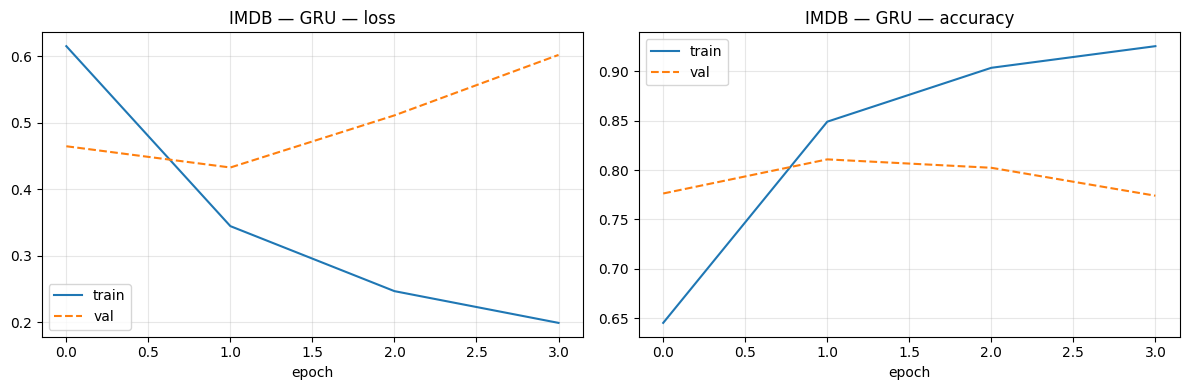

IMDB best test accuracy: 0.811


In [3]:
Xtr, ytr, Xte, yte = R.load_imdb()
cfg = R.imdb_config(); print('vocab', cfg['num_words'], '| maxlen', cfg['maxlen'])

model = keras.Sequential([
    keras.Input((cfg['maxlen'],)),
    layers.Embedding(cfg['num_words'], 32),
    layers.GRU(32),
    layers.Dense(1, activation='sigmoid'),
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()
h = model.fit(Xtr, ytr, validation_data=(Xte, yte), epochs=4, batch_size=64, verbose=0)
plot_history(h, 'accuracy', 'IMDB — GRU')
print('IMDB best test accuracy: %.3f' % max(h.history['val_accuracy']))

## Part B — Jena Climate (temperature forecasting)

`GRU(32) → Dense(1)`.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 32)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,641 (18.13 KB)

 Trainable params: 4,641 (18.13 KB)

 Non-trainable params: 0 (0.00 B)

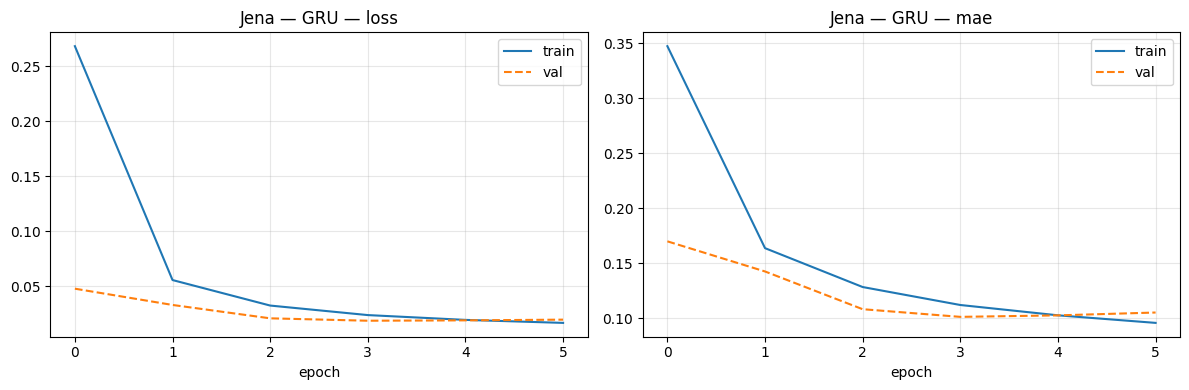

Jena best val MAE: 0.101  (~ 0.88 degC)


In [4]:
train_ds, val_ds, nfeat = R.make_jena_datasets(lookback=48, horizon=1, batch_size=128)
s = R.load_jena_series()

model = keras.Sequential([
    keras.Input((None, nfeat)),
    layers.GRU(32),
    layers.Dense(1),
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()
h = model.fit(train_ds, validation_data=val_ds, epochs=6, verbose=0)
plot_history(h, 'mae', 'Jena — GRU')
print('Jena best val MAE: %.3f  (~ %.2f degC)' % (min(h.history['val_mae']), min(h.history['val_mae'])*s['temp_std']))

## Takeaways
- GRU typically lands **very close to LSTM** on both datasets, with fewer parameters and slightly faster training.
- There's no universal winner between GRU and LSTM — it's problem-dependent, which is why the comparison notebook (08) runs them head-to-head.
- **Next:** `05_stacked_deep_rnn` — depth via `return_sequences`.